In [1]:
import os
import json
import numpy as np
import json_repair
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

def load_jsonl_data(path):
    data = []
    with open(path) as reader:
        for row in reader:
            data.append(json.loads(row))
    return data

def write_jsonl_data(data, path):
    with open(path, "w") as writer:
        for row in data:
            writer.write(json.dumps(row) + "\n")

def _parse_json_response(text: str, keys: list) -> dict:
    import re
    
    try:
        try:
            match = re.search(r"```json\s*([\s\S]*?)\s*```", text)

            json_str = match.group(1).strip()
            result = json_repair.loads(json_str)
            
        except:
            result = json_repair.loads(text)
        for key in keys:
            if key not in result:
                result[key] = None

        return result

    except Exception as e:
        response = {k: None for k in keys}
        return response

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dataclasses import dataclass, field, fields, asdict

@dataclass
class UserProfile:
    user_id: str
    religious: str
    employment: str
    marital: str
    race: str
    income: str
    area: str
    age: str
    gender: str
    bigfive: dict
    personality: list
    preferences: list
    preferences_value: list
    extra: dict = field(default_factory=dict)

    @classmethod
    def from_dict(cls, data: dict):
        data = {k.lower(): v for k, v in data.items()}

        field_names = {f.name for f in fields(cls) if f.name != "extra"}
        
        known = {name: data.get(name, None) for name in field_names}
        extra = {k: v for k, v in data.items() if k not in field_names}
        
        return cls(known, extra=extra)

    def to_dict(self) -> dict:
        base = asdict(self)
        base.update(self.extra)
        base.pop("extra", None)
        return base

    def desc(self, keys_to_drop: list = []):
        """
        Convert structured profile to a descriptive string.
        """
        base_info_parts = []

        attrs = [
            ("gender", "{}"),
            ("age", "{}"),
            ("race", "{}"),
            ("marital", "{}"),
            ("religious", "user's religion is {}"),
            ("area", "usually resides in {}"),
        ]

        for attr_name, fmt in attrs:
            if attr_name in keys_to_drop:
                continue
            value = getattr(self, attr_name, None)
            if not value:
                continue
            if attr_name == "religious":
                if value == "No religion":
                    base_info_parts.append("no religious affiliation")
                else:
                    base_info_parts.append(fmt.format(value))
            else:
                base_info_parts.append(fmt.format(value))

        base_info = ", ".join(base_info_parts)

        politics_econ_parts = []
        if "income" not in keys_to_drop and self.income:
            politics_econ_parts.append(f"the income level is {self.income}")
        if "employment" not in keys_to_drop and self.employment:
            politics_econ_parts.append(f"{self.employment}")
        politics_econ_text = ", ".join(politics_econ_parts)

        personality_text = ""
        if "personality" not in keys_to_drop and self.personality:
            personality_text = "Personality traits include: " + "、".join(self.personality)

        preferences_text = ""
        if "preferences" not in keys_to_drop and self.preferences:
            preferences_text = "Preferences expressed in daily life and interactions include: " + " ".join(self.preferences)

        parts = [base_info, politics_econ_text, personality_text, preferences_text]
        return ". ".join([p for p in parts if p])

    def __str__(self) -> str:
        return self.desc()

In [3]:
def get_eval_dataset(theme):
    root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/exp_results/logs_long_session'

    base_dir = os.path.join(root, theme)
    paths = []

    for root, dirs, files in os.walk(base_dir):
        for f in files:
            if f.startswith("sim_log"):
                paths.append(os.path.join(root, f))

    eval_for_ir = []
    eval_for_ic = []
    eval_for_pp = []
    eval_for_conv = []

    for p in paths:
        data = json.load(open(p))
        name = os.path.basename(os.path.dirname(p))

        sequence_id = data['event_sequence_info']['sequence_id']

        for i, x in enumerate(data['dialogue_log']):
            gold_intent = x['event']['intent']
            gold_sub_intents = x['event']['sub_intents']
            gold_preferences = x['user']['profile']['preferences_value']
            history = x['event']['conv_history']

            conv = ''
            pred_intents = ['']
            for j, turn in enumerate(x['dialogue']):
                if turn['role'] == 'user':
                    conv += f"[User] {turn['content']}\n"
                else:
                    conv += f"[Assistant] {turn['content']}\n"
                    
                    pre_intent = turn['pre_intent']
                    if pre_intent:
                        pred_intents.append(pre_intent)
                    eval_for_ir.append({
                        'id': '_'.join([name, str(i), str(j)]),
                        'sequence_id': sequence_id,
                        'user_id': x['user']['profile']['user_id'],
                        'gold_intent': gold_intent,
                        'gold_sub_intents': gold_sub_intents,
                        'pre_intent': pre_intent if pre_intent else ''
                    })
            
            pred_preferences = x['pre_profile']

            eval_for_pp.append({
                'id': '_'.join([name, str(i)]),
                'sequence_id': sequence_id,
                'user_id': x['user']['profile']['user_id'],
                'gold_preferences': gold_preferences,
                'pred_preferences': pred_preferences
            })

            eval_for_conv.append({
                'id': '_'.join([name, str(i)]),
                'sequence_id': sequence_id,
                'user_id': x['user']['profile']['user_id'],
                'user_profile': x['user']['profile_str'],
                'user_preferences': gold_preferences,
                "dialogue_scene": x['event']['dialogue_scene'],
                'intent': gold_intent,
                'sub_intents': gold_sub_intents,
                'conv': conv,
                'pred_intents': pred_intents,
                'conv_history': history
            })
    
    return eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv

In [4]:
import editdistance
import numpy as np
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/MODELS/Qwen3-32B')

def get_token_number(text):
    if not text:
        return 0
    
    # 方式 1：最常用，直接编码并获取 ID 列表的长度
    tokens = tokenizer.encode(text, add_special_tokens=True)
    return len(tokens)

def find_closest_str_match(text, candidates):
    """
    输入:
        text: 待匹配的字符串
        candidates: 字符串列表
    输出:
        与 text 最接近的字符串
    """
    if not candidates:
        return None
    
    for c in candidates:
        if text.lower() in c.lower() or c.lower() in text.lower():
            return c

    distances = [editdistance.eval(text.lower(), candidate.lower()) for candidate in candidates]
    
    min_index = distances.index(min(distances))
    
    return candidates[min_index]

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

MODELS_NAME = {
    'gemma-3-27b-it': 'Gemma3-it 27B',
    'gpt-oss-20b': 'gpt-oss 20B',
    'Meta-Llama-3.1-8B-Instruct': 'Llama3.1-it 8B',
    'Qwen3-32B': 'Qwen3 32B',
    'Qwen3-14B': 'Qwen3 14B',
    'deepseek-chat': 'DeepSeek-V3.2'
}

light_red_green = sns.diverging_palette(
    10,    # green hue
    0,     # red hue
    s=60,  # 饱和度（越小越淡，50~70 很合适）
    l=90,  # 亮度（越大越浅，85~95 是论文安全区）
    as_cmap=True
)


sns.set_context(
    "paper",                 # paper / notebook / talk / poster
    font_scale=1.5            # 核心控制参数（整体放大倍数）
)

mpl.rcParams.update({
    "font.size": 14,          # 默认文字
    "axes.titlesize": 14,     # 子图标题
    "axes.labelsize": 14,     # x/y 轴标题
    "xtick.labelsize": 14,     # x 轴刻度
    "ytick.labelsize": 14,     # y 轴刻度
    "legend.fontsize": 14,
})

def plot_long_horizon_ic_heatmap(
    all_ex_stats,
    all_im_stats,
    model_names,
    *,
    model_label_fn=None,
    figsize=(8, 6),
    show_token_value=True,
    vmin=0.0,
    vmax=100.0,
    annotate=True,
    annot_fmt=".0f"
):
    """
    Plot long-horizon IC heatmaps (explicit / implicit) using seaborn,
    with per-cell score annotations.

    Parameters
    ----------
    all_ex_stats : dict
        model_name -> { token_mean : ic_value }
    all_im_stats : dict
        model_name -> { token_mean : ic_value }
    model_names : list
        Ordered list of model names (x-axis order).
    model_label_fn : callable, optional
        Function to convert model_name -> display label.
    figsize : tuple
        Figure size.
    show_token_value : bool
        Whether to show token_mean as y-axis labels.
    vmin, vmax : float
        Color scale range.
    annotate : bool
        Whether to annotate each cell with its value.
    annot_fmt : str
        Annotation format, default ".0f" (integer).
    """

    def build_matrix(all_stats):
        token_set = set()
        for m in model_names:
            token_set.update(all_stats.get(m, {}).keys())

        token_axis = sorted(token_set)
        token2idx = {t: i for i, t in enumerate(token_axis)}

        mat = np.full((len(token_axis), len(model_names)), np.nan)
        for j, m in enumerate(model_names):
            for t, v in all_stats.get(m, {}).items():
                mat[token2idx[t], j] = v * 100

        return mat, token_axis

    # build matrices
    ex_mat, token_axis = build_matrix(all_ex_stats)
    im_mat, _ = build_matrix(all_im_stats)

    # model labels
    if model_label_fn is None:
        model_labels = [MODELS_NAME[m.split('_')[-3]] for m in model_names]
    else:
        model_labels = [model_label_fn(m) for m in model_names]

    # y-axis labels
    if show_token_value:
        y_labels = [f'{int(t // 1000)}K' for t in token_axis]
        y_label_name = 'Conversation History Tokens'
    else:
        y_labels = [f'Bin {i + 1}' for i in range(len(token_axis))]
        y_label_name = 'Context Length (Short → Long)'

    # plotting
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # ----- Explicit -----
    sns.heatmap(
        ex_mat,
        ax=axes[0],
        cmap='YlGnBu',
        vmin=vmin,
        vmax=vmax,
        xticklabels=model_labels,
        yticklabels=y_labels,
        annot=annotate,
        fmt=annot_fmt,
        cbar=False,
        # annot_kws={"color": "black"}
    )
    axes[0].set_title('Explicit Intention (I.C.)')
    # axes[0].set_xlabel('Model')
    axes[0].set_ylabel(y_label_name)

    # ----- Implicit -----
    sns.heatmap(
        im_mat,
        ax=axes[1],
        cmap='YlGnBu',
        vmin=vmin,
        vmax=vmax,
        xticklabels=model_labels,
        yticklabels=y_labels,
        annot=annotate,
        fmt=annot_fmt,
        cbar=True,
        # annot_kws={"color": "black"},
    )
    axes[1].set_title('Implicit Intention (I.C.)')
    # axes[1].set_xlabel('Model')
    # axes[1].set_ylabel(y_label_name)
    
    # axes[0].set_xticklabels(model_labels, rotation=45, ha='right')
    # axes[1].set_xticklabels(model_labels, rotation=45, ha='right')
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    # plt.savefig("/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/long_horizon_ic_heatmap.pdf", bbox_inches="tight", format='pdf')
    plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

MODELS_NAME = {
    'gemma-3-27b-it': 'Gemma3-it 27B',
    'gpt-oss-20b': 'gpt-oss 20B',
    'Meta-Llama-3.1-8B-Instruct': 'Llama3.1-it 8B',
    'Qwen3-32B': 'Qwen3 32B',
    'Qwen3-14B': 'Qwen3 14B',
    'deepseek-chat': 'DeepSeek-V3.2',
    'gpt-5': 'GPT-5',
    'claude-sonnet-4-5-20250929': 'Claude Sonnet 4.5'
}

light_red_green = sns.diverging_palette(
    10,    # green hue
    0,     # red hue
    s=60,  # 饱和度（越小越淡，50~70 很合适）
    l=90,  # 亮度（越大越浅，85~95 是论文安全区）
    as_cmap=True
)


sns.set_context(
    "paper",                 # paper / notebook / talk / poster
    font_scale=1.5            # 核心控制参数（整体放大倍数）
)

mpl.rcParams.update({
    "font.size": 16,          # 默认文字
    "axes.titlesize": 16,     # 子图标题
    "axes.labelsize": 16,     # x/y 轴标题
    "xtick.labelsize": 16,     # x 轴刻度
    "ytick.labelsize": 16,     # y 轴刻度
    "legend.fontsize": 16,
})

def plot_long_horizon_ic_heatmap(
    all_ex_stats,
    all_im_stats,
    model_names,
    *,
    model_label_fn=None,
    figsize=(10, 10),
    show_token_value=True,
    vmin=0.0,
    vmax=100.0,
    annotate=True,
    annot_fmt=".0f"
):
    """
    Plot long-horizon IC heatmaps (explicit / implicit),
    with models on y-axis and tokens on x-axis.
    """

    def build_matrix(all_stats):
        # collect all token bins
        token_set = set()
        for m in model_names:
            token_set.update(all_stats.get(m, {}).keys())
        token_axis = sorted(token_set)

        token2idx = {t: i for i, t in enumerate(token_axis)}
        model2idx = {m: i for i, m in enumerate(model_names)}

        # shape: (n_models, n_tokens)
        mat = np.full((len(model_names), len(token_axis)), np.nan)

        for m, stats in all_stats.items():
            if m not in model2idx:
                continue
            i = model2idx[m]
            for t, v in stats.items():
                j = token2idx[t]
                mat[i, j] = v * 100

        return mat, token_axis

    # build matrices
    ex_mat, token_axis = build_matrix(all_ex_stats)
    im_mat, _ = build_matrix(all_im_stats)

    # model labels (y-axis)
    if model_label_fn is None:
        model_labels = [MODELS_NAME[m.split('_')[-3]] for m in model_names]
    else:
        model_labels = [model_label_fn(m) for m in model_names]

    # token labels (x-axis)
    if show_token_value:
        x_labels = [f'{int(t // 1000)}K' for t in token_axis]
        x_label_name = 'Conversation History Tokens'
    else:
        x_labels = [f'Bin {i + 1}' for i in range(len(token_axis))]
        x_label_name = 'Context Length (Short → Long)'

    # plotting
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharey=True)

    # ----- Explicit -----
    sns.heatmap(
        ex_mat,
        ax=axes[0],
        cmap='YlGnBu',
        vmin=vmin,
        vmax=vmax,
        xticklabels=x_labels,
        yticklabels=model_labels,
        annot=annotate,
        fmt=annot_fmt,
        cbar=True,
    )
    axes[0].set_title('Explicit Intention (I.C.)')
    # axes[0].set_xlabel(x_label_name)
    # axes[0].set_ylabel('Model')

    # ----- Implicit -----
    sns.heatmap(
        im_mat,
        ax=axes[1],
        cmap='YlGnBu',
        vmin=vmin,
        vmax=vmax,
        xticklabels=x_labels,
        yticklabels=model_labels,
        annot=annotate,
        fmt=annot_fmt,
        cbar=True,
    )
    axes[1].set_title('Implicit Intention (I.C.)')
    axes[1].set_xlabel(x_label_name)

    # token label rotation（横轴现在是 token）
    plt.setp(axes[0].get_yticklabels(), rotation=0, ha='right')
    plt.setp(axes[1].get_yticklabels(), rotation=0, ha='right')

    plt.tight_layout()
    # plt.savefig(
    #     "/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/pics/long_horizon_ic_heatmap_horizontal.pdf",
    #     bbox_inches="tight",
    #     format="pdf"
    # )
    plt.show()

In [6]:
# IR & IC
root = '/inspire/hdd/project/socialsimulation/linjiayu-CZXS25120090/FYDUAN/ai_assistant/evaluation/assistant_performance_long_session'

evaluators = [
    'gpt_oss_120b',
    # 'llama3_70b',
    # 'qwen3_32b',
    # 'deepseek_chat'
]

models = [
    'main_user_Qwen3-32B_assistant_gemma-3-27b-it_long_session',
    'main_user_Qwen3-32B_assistant_gpt-oss-20b_long_session',
    'main_user_Qwen3-32B_assistant_Meta-Llama-3.1-8B-Instruct_long_session',
    'main_user_Qwen3-32B_assistant_Qwen3-32B_long_session',
    'main_user_Qwen3-32B_assistant_Qwen3-14B_long_session',
    'main_user_Qwen3-32B_assistant_deepseek-chat_long_session',
    'main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_long_session',
    'main_user_Qwen3-32B_assistant_gpt-5_long_session'
]

def process_ir_one(item):
    output = _parse_json_response(item['output'], [])
    
    try:
        if isinstance(output, list):
            output = output[0]
        candidates = list(output.keys())
    except:
        candidates = []
    
    for d in item['sub_intents']:
        k = find_closest_str_match(d['description'], candidates)
        try:
            d['ir_score'] = int(output[k])
        except Exception:
            d['ir_score'] = 0
        
    return item

def process_ic_one(item, ir_results=None):
    output = _parse_json_response(item['output'], [])
    
    try:
        if isinstance(output, list):
            output = output[0]
        candidates = list(output.keys())
    except:
        candidates = []
    
    for d in item['sub_intents']:
        k = find_closest_str_match(d['description'], candidates)
        _id = f'{x["id"]}@{d["description"]}@{d["type"]}@{x["user_id"]}'
        try:
            d['ic_score'] = int(output[k])
        except Exception:
            d['ic_score'] = 0
        # if ir_results[_id] > 0:
        #     try:
        #         d['ic_score'] = int(output[k])
        #     except Exception:
        #         d['ic_score'] = 0
        # else:
        #     d['ic_score'] = 0
        
    return item

import numpy as np

def long_horizon_stats(results, num_groups=10):
    # 收集 (tokens, value) 按类型分开
    data = {
        "implicit": [],
        "explicit": []
    }

    for k, v in results.items():
        tokens = int(k.split('@')[-3])
        type_ = k.split('@')[-2]
        if type_ in data:
            data[type_].append((tokens, v))

    # return data['implicit'], data['explicit']
    # 若两类都为空，直接返回
    if not data["implicit"] and not data["explicit"]:
        return {}, {}

    # 用所有 token 的 min/max 来统一分桶，保证可比性
    all_tokens = []
    for t in data:
        all_tokens += [x[0] for x in data[t]]

    all_tokens = np.array(all_tokens, dtype=float)
    t_min, t_max = all_tokens.min(), all_tokens.max()

    if t_min == t_max:
        # 所有 token 相同，退化为单桶
        implicit_stats = {}
        explicit_stats = {}
        if data["implicit"]:
            implicit_stats[float(t_min)] = float(
                np.mean([v for _, v in data["implicit"]])
            )
        if data["explicit"]:
            explicit_stats[float(t_min)] = float(
                np.mean([v for _, v in data["explicit"]])
            )
        return implicit_stats, explicit_stats

    bins = np.linspace(t_min, t_max, num_groups + 1)

    def compute_stats(pairs):
        if not pairs:
            return {}
        tokens_arr = np.array([t for t, _ in pairs], dtype=float)
        values_arr = np.array([v for _, v in pairs], dtype=float)

        stats = {}
        for i in range(num_groups):
            left, right = bins[i], bins[i + 1]
            if i == num_groups - 1:
                mask = (tokens_arr >= left) & (tokens_arr <= right)
            else:
                mask = (tokens_arr >= left) & (tokens_arr < right)

            if not np.any(mask):
                continue

            token_mean = float(tokens_arr[mask].mean())
            value_mean = float(values_arr[mask].mean())
            stats[token_mean] = value_mean
        return stats

    implicit_stats = compute_stats(data["implicit"])
    explicit_stats = compute_stats(data["explicit"])

    return implicit_stats, explicit_stats

plt.figure(figsize=(10, 10))

total_ex_stats = {}
total_im_stats = {}

for model in models:
    eval_for_ir, eval_for_ic, eval_for_pp, eval_for_conv = get_eval_dataset(model)
    id2history = {x['id']: '\n'.join(x['conv_history']) for x in eval_for_conv}
    
    ic_results = {}
    plot_ic_results = {}
    for evaluator in evaluators:
        sub_ic_results = load_jsonl_data(os.path.join(root, evaluator, model, 'ic_results.jsonl'))
        for x in tqdm(sub_ic_results):
            # x = process_ic_one(x, e_ir_results[evaluator])
            x = process_ic_one(x)
            history_token = get_token_number(id2history[x['id']])
            for s in x['sub_intents']:
                _id = f'{x["id"]}@{s["description"]}@{str(history_token)}@{s["type"]}@{x["user_id"]}'
                if _id not in ic_results:
                    ic_results[_id] = s['ic_score']
                else:
                    ic_results[_id] += s['ic_score']
    
    e_ic_score = []
    i_ic_score = []
    final_ic_results = load_jsonl_data(os.path.join(root, evaluators[0], model, 'ic_results.jsonl'))
    for x in tqdm(final_ic_results):
        explicit_ic = []
        implicit_ic = []
        history_token = get_token_number(id2history[x['id']])
        for s in x['sub_intents']:
            _id = f'{x["id"]}@{s["description"]}@{str(history_token)}@{s["type"]}@{x["user_id"]}'
            s['ic_score'] = ic_results[_id] * 1.0 / len(evaluators)
            if s['type'] == 'explicit':
                explicit_ic.append(s['ic_score'])
            else:
                implicit_ic.append(s['ic_score'])
        
        e_ic_score.append(np.mean(explicit_ic))
        i_ic_score.append(np.mean(implicit_ic))
        
        _idd = f'{x["id"]}@###@{str(history_token)}@explicit@{x["user_id"]}'
        plot_ic_results[_idd] = np.mean(explicit_ic)
        _idd = f'{x["id"]}@###@{str(history_token)}@implicit@{x["user_id"]}'
        plot_ic_results[_idd] = np.mean(implicit_ic)
    
    print(model)
    print(f'Explicit IC: {np.mean(e_ic_score) * 100: .1f}')
    print(f'Implicit IC: {np.mean(i_ic_score) * 100: .1f}')
    
    import matplotlib.pyplot as plt

    im_stats, ex_stats = long_horizon_stats(plot_ic_results, num_groups=7)
    total_ex_stats[model] = ex_stats
    total_im_stats[model] = im_stats
    # im_stats.sort(key = lambda x: x[0])
    # plt.plot([x[0] for x in im_stats], [x[1] for x in im_stats])

    # color = None
    # # print(im_stats)
    # # explicit（先画，拿到颜色）
    # if ex_stats:
    #     ex_items = sorted(ex_stats.items())
    #     ex_keys, ex_vals = zip(*ex_items)
    #     line_exp, = plt.plot(
    #         ex_keys, ex_vals,
    #         linestyle='--',
    #         marker='o',
    #         label=f"{model.split('_')[-3]}_explicit"
    #     )
    #     color = line_exp.get_color()  # 关键：取颜色

    # # implicit（复用颜色）
    # if im_stats:
    #     im_items = sorted(im_stats.items())
    #     im_keys, im_vals = zip(*im_items)
    #     plt.plot(
    #         im_keys, im_vals,
    #         linestyle='-',
    #         marker='*',
    #         color=color,
    #         label=f"{model.split('_')[-3]}_implicit"
    #     )

# plot_long_horizon_ic_heatmap(
#     total_ex_stats,
#     total_im_stats,
#     models
# )
# plt.legend(
#     loc="lower left",
#     bbox_to_anchor=(1.01, 0.0),  # 向左移，靠下
#     frameon=True
# )
# plt.grid()
# plt.show()

100%|██████████| 1309/1309 [00:13<00:00, 95.46it/s] 


main_user_Qwen3-32B_assistant_gemma-3-27b-it_long_session
Explicit IC:  83.7
Implicit IC:  40.5


100%|██████████| 1309/1309 [00:13<00:00, 93.84it/s] 


main_user_Qwen3-32B_assistant_gpt-oss-20b_long_session
Explicit IC:  88.4
Implicit IC:  41.2


100%|██████████| 1309/1309 [00:14<00:00, 91.80it/s] 


...

100%|██████████| 1309/1309 [00:14<00:00, 92.55it/s] 


main_user_Qwen3-32B_assistant_claude-sonnet-4-5-20250929_long_session
Explicit IC:  87.0
Implicit IC:  56.3


100%|██████████| 1076/1076 [00:12<00:00, 88.66it/s]

main_user_Qwen3-32B_assistant_gpt-5_long_session
Explicit IC:  91.7
Implicit IC:  70.7


<Figure size 1000x1000 with 0 Axes>

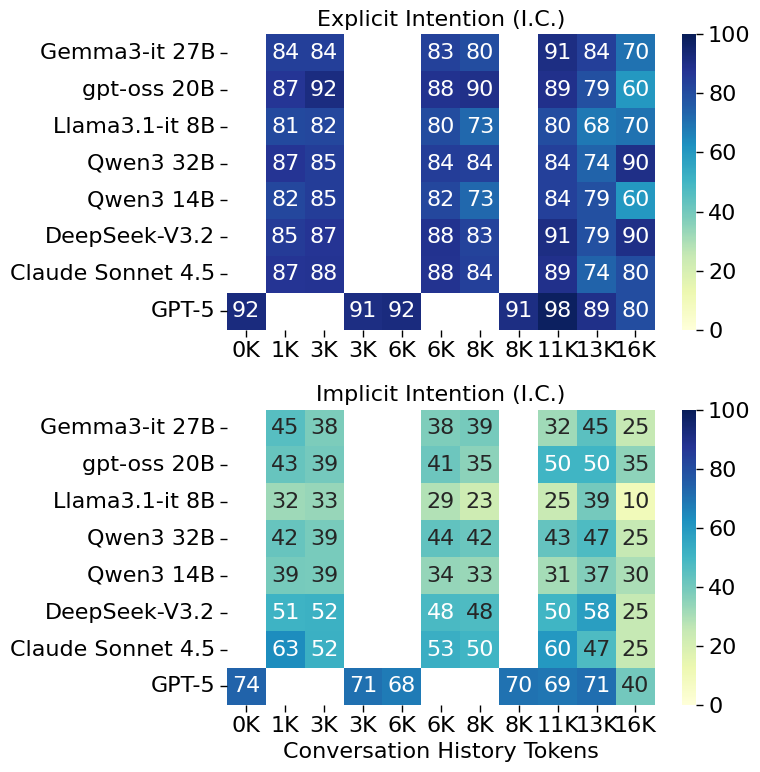

In [7]:
plot_long_horizon_ic_heatmap(
    total_ex_stats,
    total_im_stats,
    models,
    figsize=(8, 8)
)
# plt.legend(
#     loc="lower left",
#     bbox_to_anchor=(1.01, 0.0),  # 向左移，靠下
#     frameon=True
# )
# plt.grid()
plt.show()